# SmolVLM2 — Inference Demo

SmolVLM2 is HuggingFace's production-quality small VLM. It follows the same
architectural idea we built in mini-VLM (vision encoder → projector → LM),
but was trained end-to-end on large-scale multimodal data instead of just
training a connector.

```
mini-VLM  : CLIP ViT-B/32 (frozen) → MLP Connector (trained) → SmolLM2-135M-Instruct (frozen)
SmolVLM2  : SigLIP-400M  (trained) → Pixel-shuffle projector  (trained) → SmolLM2 (trained)
```

Models available (pick by size vs speed):
- `HuggingFaceTB/SmolVLM2-256M-Video-Instruct` — fastest, ~256 M params
- `HuggingFaceTB/SmolVLM2-500M-Video-Instruct` — balanced
- `HuggingFaceTB/SmolVLM2-2.2B-Instruct`       — best quality

## 0. Project root & imports

In [1]:
import rootutils

root = rootutils.setup_root(".", indicator=".project-root", pythonpath=True)
print(f"Project root: {root}")

Project root: /Users/gsoykan/Desktop/yanan-desktop/inzva/applied-ai-10/mini-vlm


In [2]:
import logging

import matplotlib.pyplot as plt
import torch
from datasets import load_dataset
from transformers import AutoModelForImageTextToText, AutoProcessor

# SmolVLMProcessor internally injects `num_frames`/`fps` kwargs that the new
# ProcessorMixin checker flags — this is a library bug in processing_smolvlm.py.
logging.getLogger("transformers.processing_utils").setLevel(logging.ERROR)

DEVICE = (
    torch.device("mps")
    if torch.backends.mps.is_available()
    else torch.device("cuda")
    if torch.cuda.is_available()
    else torch.device("cpu")
)
print(f"Device: {DEVICE}")

Device: mps


## 1. Load SmolVLM2

In [3]:
MODEL_NAME = "HuggingFaceTB/SmolVLM2-256M-Video-Instruct"  # swap for 500M or 2.2B

processor = AutoProcessor.from_pretrained(MODEL_NAME)

model = AutoModelForImageTextToText.from_pretrained(
    MODEL_NAME,
    dtype=torch.float32,
    device_map=DEVICE,
)
model.eval()

total = sum(p.numel() for p in model.parameters())
print(f"Loaded {MODEL_NAME}")
print(f"Total params: {total / 1e6:.0f} M")

Loading weights:   0%|          | 0/471 [00:00<?, ?it/s]

Loaded HuggingFaceTB/SmolVLM2-256M-Video-Instruct
Total params: 256 M


## 2. Inference helper

In [4]:
def generate(pil_image, prompt="Describe this image briefly.", max_new_tokens=32):
    """PIL Image + text prompt → caption string."""
    messages = [
        {
            "role": "user",
            "content": [
                {"type": "image", "image": pil_image.convert("RGB")},
                {"type": "text", "text": prompt},
            ],
        }
    ]
    inputs = processor.apply_chat_template(
        messages,
        add_generation_prompt=True,
        tokenize=True,
        return_dict=True,
        return_tensors="pt",
    ).to(DEVICE)

    with torch.no_grad():
        output_ids = model.generate(**inputs, max_new_tokens=max_new_tokens, do_sample=False)

    generated_ids = output_ids[:, inputs["input_ids"].shape[1] :]
    return processor.batch_decode(generated_ids, skip_special_tokens=True)[0].strip()

## 3. CIFAR-10 — one per class

In [5]:
_CLASSES = [
    "airplane",
    "automobile",
    "bird",
    "cat",
    "deer",
    "dog",
    "frog",
    "horse",
    "ship",
    "truck",
]

cifar_test = load_dataset("uoft-cs/cifar10", split="test")

samples = {}
for row in cifar_test:
    label = row["label"]
    if label not in samples:
        samples[label] = row
    if len(samples) == 10:
        break

print(f"Loaded one example per class ({len(samples)} total).")

Loaded one example per class (10 total).


In [6]:
results = []
for label_idx in range(10):
    row = samples[label_idx]
    img = row["img"].convert("RGB")
    caption = generate(img)
    reference = f"a photo of a {_CLASSES[label_idx]}"
    results.append((img, caption, reference))
    print(f"[{_CLASSES[label_idx]:>10s}]  {caption}")

[  airplane]  The image is a close-up of a book cover. The cover is predominantly white with a blue and red stripe at the top. The book cover is titled
[automobile]  The image is a close-up of a car. The car is white and is parked on a road. The car has a roof and a side door.
[      bird]  The image captures a close-up view of a person's hands holding a chicken. The chicken is black with red legs and a red head. The hands are
[       cat]  The image is a stylized illustration of a dog. The dog is depicted in a relaxed manner, lying down with its head resting on its paws. The dog's
[      deer]  The image is a close-up of a deer's head. The deer is in the foreground, and the background is blurred, making it difficult to discern any
[       dog]  The image depicts a small dog with a white and brown coat. The dog is standing on a grassy area, possibly a park or a grassy field, with a
[      frog]  The image features a small brown frog sitting on a green leaf. The frog appears to be resti

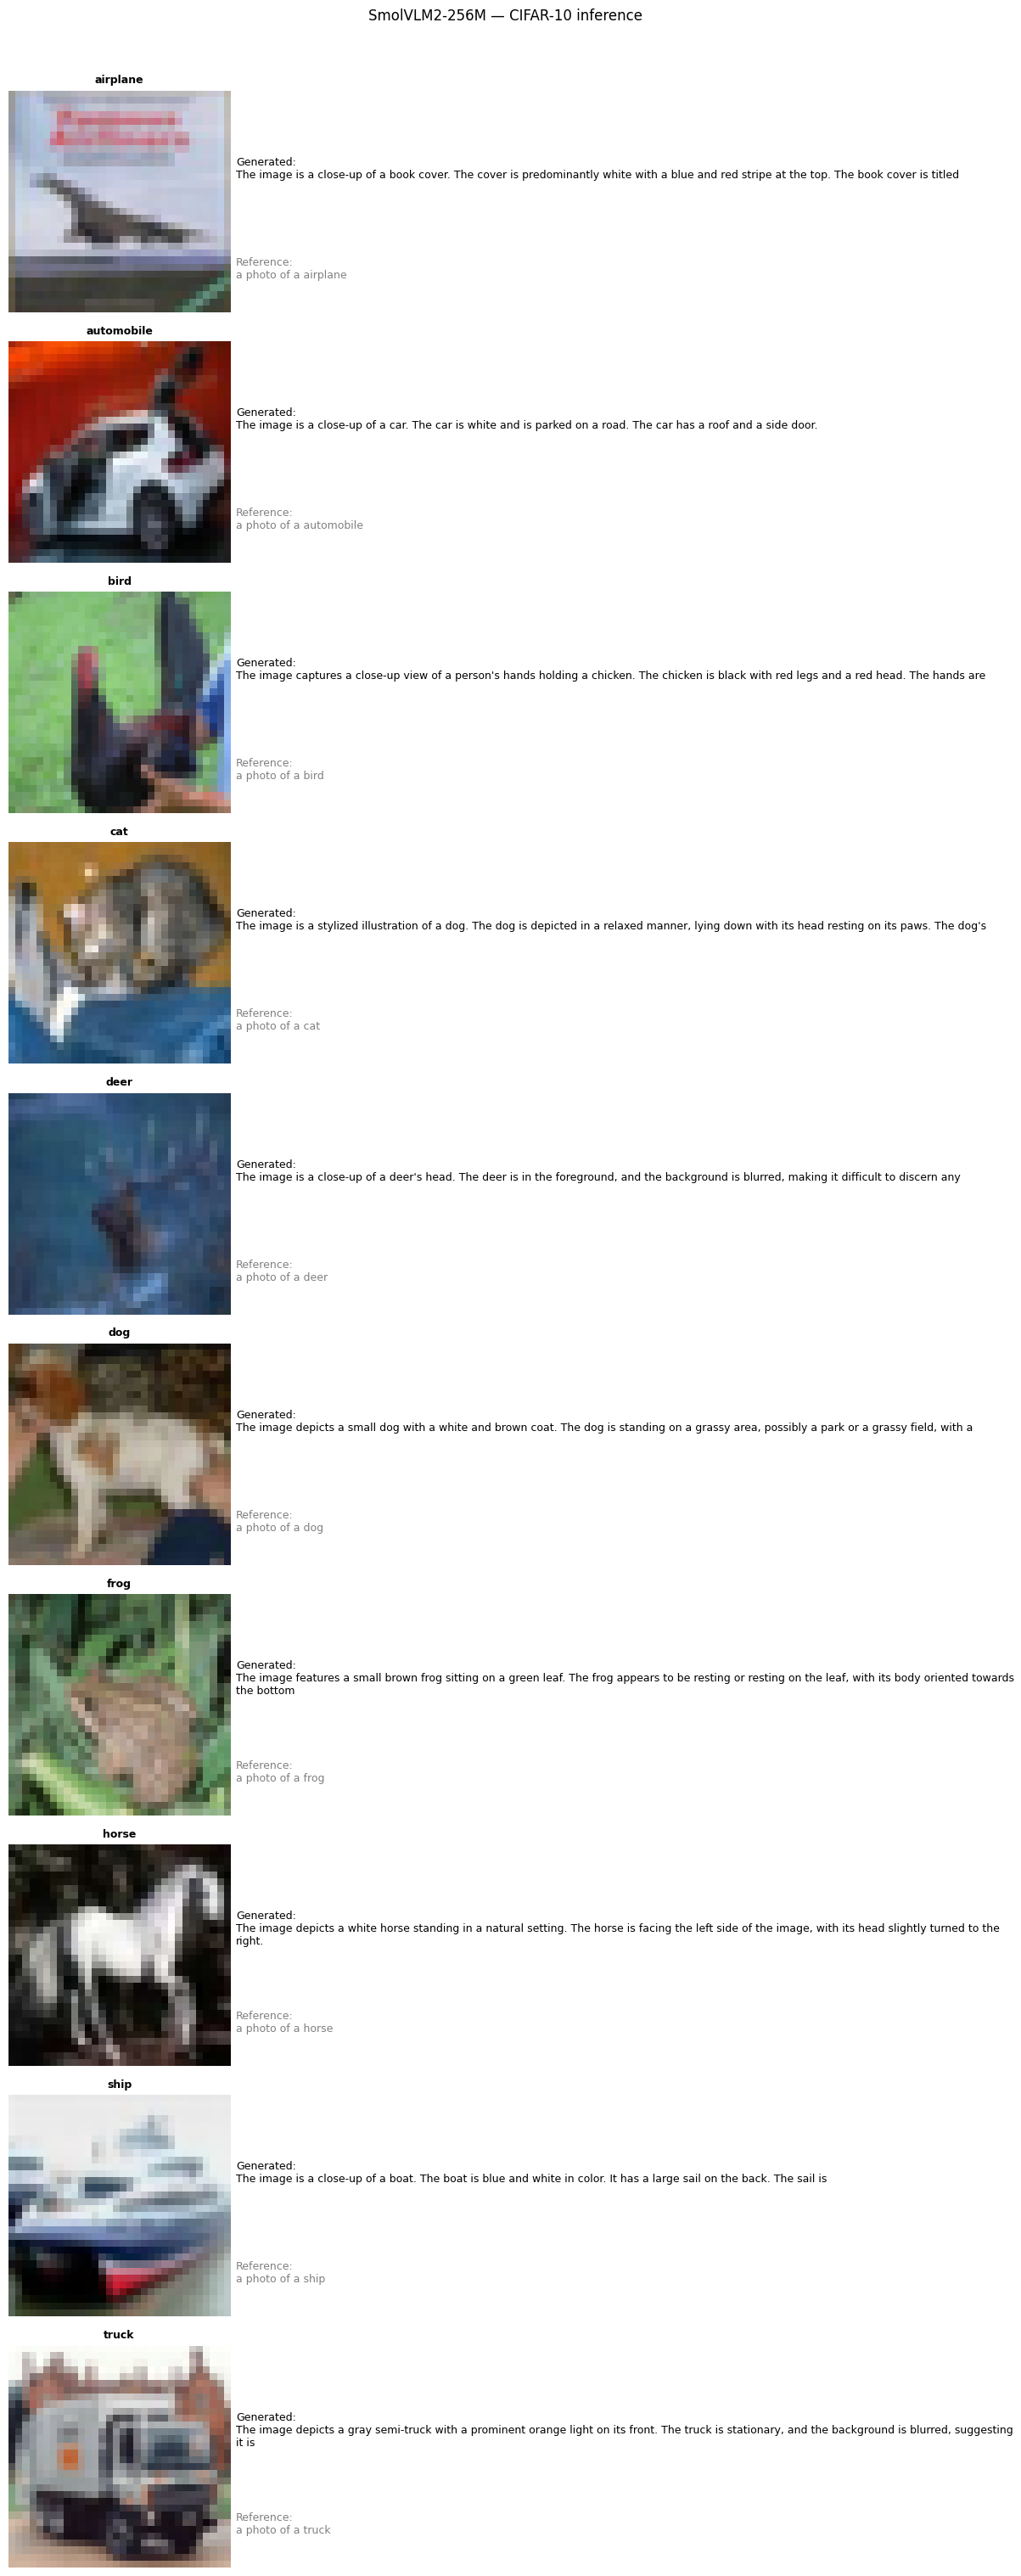

In [7]:
n = len(results)
fig, axes = plt.subplots(n, 2, figsize=(12, 3 * n), gridspec_kw={"width_ratios": [1, 3]})

for i, (img, caption, reference) in enumerate(results):
    # Left: image
    axes[i, 0].imshow(img)
    axes[i, 0].axis("off")
    axes[i, 0].set_title(_CLASSES[i], fontsize=9, fontweight="bold")

    # Right: generated + reference text
    axes[i, 1].axis("off")
    axes[i, 1].text(
        0.0,
        0.70,
        f"Generated:\n{caption}",
        fontsize=9,
        va="top",
        transform=axes[i, 1].transAxes,
        wrap=True,
    )
    axes[i, 1].text(
        0.0,
        0.25,
        f"Reference:\n{reference}",
        fontsize=9,
        va="top",
        color="gray",
        transform=axes[i, 1].transAxes,
    )

fig.suptitle("SmolVLM2-256M — CIFAR-10 inference", fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig("smolvlm2_cifar10.png", dpi=100, bbox_inches="tight")
plt.show()

## 4. Open-ended questions

SmolVLM2 is an instruction-tuned VLM — it can answer arbitrary questions about an image, not just describe it.

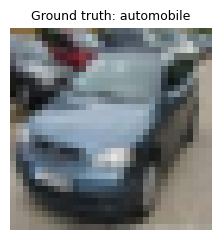

Q: Describe this image briefly.
A: The image depicts a car parked in an outdoor setting. The car is a blue sedan, identifiable by its dark body and the visible headlights. The car is positioned in the foreground, with the background showing a parking lot with other cars

Q: What is the main subject of this image?
A: The image depicts a car parked in an outdoor setting. The car is a blue sedan, identifiable by its sleek design and the visible headlights. The car is positioned in the foreground, with the background showing a parking lot or a similar

Q: What colors are most prominent?
A: The most prominent colors in the image are blue and black.



In [8]:
import random

row = cifar_test[random.randint(0, len(cifar_test) - 1)]
img = row["img"].convert("RGB")
gt = _CLASSES[row["label"]]

questions = [
    "Describe this image briefly.",
    "What is the main subject of this image?",
    "What colors are most prominent?",
]

plt.figure(figsize=(2.5, 2.5))
plt.imshow(img)
plt.axis("off")
plt.title(f"Ground truth: {gt}", fontsize=9)
plt.tight_layout()
plt.show()

for q in questions:
    answer = generate(img, prompt=q, max_new_tokens=48)
    print(f"Q: {q}")
    print(f"A: {answer}")
    print()

## 5. Try your own image

In [ ]:
# Replace with any image path
# img = Image.open("/path/to/your/image.jpg")

row = cifar_test[random.randint(0, len(cifar_test) - 1)]
img = row["img"].convert("RGB")

caption = generate(img, max_new_tokens=64)
print(caption)

plt.figure(figsize=(3, 3))
plt.imshow(img)
plt.axis("off")
plt.title(caption, fontsize=8, wrap=True)
plt.tight_layout()
plt.show()

## 6. MLX — Video Understanding

[MLX](https://github.com/ml-explore/mlx) is Apple's array framework that runs natively on the Apple Neural Engine. Running SmolVLM2 through `mlx-vlm` is faster on Apple Silicon than PyTorch MPS — weights are stored in a quantised MLX format (513 MB vs ~1 GB fp32).

We use the `mlx-vlm` CLI directly from notebook cells via `sys.executable`, which ensures the venv Python is used rather than the system Python.

In [ ]:
%pip install -q mlx-vlm

In [11]:
from huggingface_hub import hf_hub_download

# Short sample clip from HF — swap VIDEO_PATH for any local .mp4 if you have one
VIDEO_PATH = hf_hub_download(
    repo_id="raushan-testing-hf/videos-test",
    filename="sample_demo_1.mp4",
    repo_type="dataset",
)
print(f"Video: {VIDEO_PATH}")

Video: /Users/gsoykan/.cache/huggingface/hub/datasets--raushan-testing-hf--videos-test/snapshots/4cba700bd771f44d72b549253da025c32e944d42/sample_demo_1.mp4


In [ ]:
# Image understanding
!{sys.executable} -m mlx_vlm.generate \
    --model mlx-community/SmolVLM2-256M-Video-Instruct-mlx \
    --image https://huggingface.co/datasets/huggingface/documentation-images/resolve/main/bee.jpg \
    --prompt "Can you describe this image?"

In [17]:
# Video understanding
!{sys.executable} -m mlx_vlm.video_generate \
    --model mlx-community/SmolVLM2-256M-Video-Instruct-mlx \
    --video {VIDEO_PATH} \
    --prompt "Describe what is happening in this video." \
    --max-tokens 128

objc[67711]: Class AVFFrameReceiver is implemented in both /Users/gsoykan/Desktop/yanan-desktop/inzva/applied-ai-10/mini-vlm/.venv/lib/python3.13/site-packages/av/.dylibs/libavdevice.62.1.100.dylib (0x111dfc3a8) and /Users/gsoykan/Desktop/yanan-desktop/inzva/applied-ai-10/mini-vlm/.venv/lib/python3.13/site-packages/cv2/.dylibs/libavdevice.61.3.100.dylib (0x11c28c3a8). This may cause spurious casting failures and mysterious crashes. One of the duplicates must be removed or renamed.
objc[67711]: Class AVFAudioReceiver is implemented in both /Users/gsoykan/Desktop/yanan-desktop/inzva/applied-ai-10/mini-vlm/.venv/lib/python3.13/site-packages/av/.dylibs/libavdevice.62.1.100.dylib (0x111dfc3f8) and /Users/gsoykan/Desktop/yanan-desktop/inzva/applied-ai-10/mini-vlm/.venv/lib/python3.13/site-packages/cv2/.dylibs/libavdevice.61.3.100.dylib (0x11c28c3f8). This may cause spurious casting failures and mysterious crashes. One of the duplicates must be removed or renamed.
This is a beta version of th